# **Cell 1 – Structired Directory Scraping Function**

In [1]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
from IPython.display import display

# ============================================================
# CONFIG
# ============================================================
ROOT = Path("/kaggle/input")
GROUP_NAME = "special-hr-etc"

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.gif', '.webp'}
META_EXTS  = {'.csv', '.tsv', '.xlsx', '.xls', '.json', '.txt', '.xml'}

structure = {}
meta_files = []

def is_image(p: Path) -> bool:
    return p.suffix.lower() in IMAGE_EXTS

def walk(path: Path, current_dict: dict):
    print(f"Checking → {path}")
    
    try:
        entries = sorted(path.iterdir())
    except PermissionError:
        print(f"  ⚠️  Permission denied: {path}")
        return

    has_image = any(is_image(e) for e in entries if e.is_file())
    
    if has_image:
        current_dict["__contains_images__"] = True
        current_dict["__subdirs__"] = [e.name for e in entries if e.is_dir()]
        print(f"  → Contains images. Stopping deeper traversal.")
        return

    for entry in entries:
        if entry.is_dir():
            current_dict[entry.name] = {}
            walk(entry, current_dict[entry.name])
        elif entry.suffix.lower() in META_EXTS:
            meta_files.append(str(entry))
            current_dict.setdefault("__meta_files__", []).append(entry.name)
            print(f"  → Found metadata: {entry.name}")

# ============================================================
# RUN SCAN
# ============================================================
print(f"Scanning structure for group: {GROUP_NAME}\n")
walk(ROOT, structure)

# Save structure
structure_path = f"/kaggle/working/{GROUP_NAME}_structure.json"
with open(structure_path, "w") as f:
    json.dump(structure, f, indent=2)
print(f"\n✅ Structure JSON saved → {structure_path}")

# ============================================================
# PATHS DB SKELETON
# ============================================================
paths_db = {
    "group": GROUP_NAME,
    "created": datetime.now().isoformat(),
    "datasets": {
        "Hypertensive Retinopathy": {
            "kaggle_slug": "zoya77/hypertensive-retinopathy-fundus-image-dataset",
            "root": "",
            "images_folder": "",
            "csv": "",
            "type": "folder_based",
            "classes": ["Normal", "Hypertensive Retinopathy"],
            "notes": "Small specialized HR dataset"
        }
    }
}

paths_path = f"/kaggle/working/{GROUP_NAME}_paths_db.json"
with open(paths_path, "w") as f:
    json.dump(paths_db, f, indent=2)
print(f"✅ Paths DB skeleton saved → {paths_path}")

# ============================================================
# SHOW METADATA
# ============================================================
print("\n===== METADATA / CSV FILES FOUND =====")
if meta_files:
    df_meta = pd.DataFrame({
        "Metadata File": meta_files,
        "Parent Folder": [str(Path(p).parent) for p in meta_files]
    })
    display(df_meta)
else:
    print("No CSV / metadata files found.")

print("\nDone. Paste the scan output.")

Scanning structure for group: special-hr-etc

Checking → /kaggle/input
Checking → /kaggle/input/datasets
Checking → /kaggle/input/datasets/zoya77
Checking → /kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset
Checking → /kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset/Eye Disease dataset
Checking → /kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset/Eye Disease dataset/Hypertensive Retinopathy
  → Contains images. Stopping deeper traversal.
Checking → /kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset/Eye Disease dataset/Normal Fundus
  → Contains images. Stopping deeper traversal.

✅ Structure JSON saved → /kaggle/working/special-hr-etc_structure.json
✅ Paths DB skeleton saved → /kaggle/working/special-hr-etc_paths_db.json

===== METADATA / CSV FILES FOUND =====
No CSV / metadata files found.

Done. Paste the scan output.


# **Cell 2 – Master Function For Analysis**

In [2]:
import json
from datetime import datetime

paths_db = {
    "group": "special-hr-etc",
    "created": datetime.now().isoformat(),
    "datasets": {
        "Hypertensive Retinopathy": {
            "kaggle_slug": "zoya77/hypertensive-retinopathy-fundus-image-dataset",
            "root": "/kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset/Eye Disease dataset",
            "images_folder": "/kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset/Eye Disease dataset",
            "type": "folder_based",
            "classes": ["Normal Fundus", "Hypertensive Retinopathy"],
            "notes": "Small specialized HR dataset (273 images)"
        }
    }
}

with open("/kaggle/working/special-hr-etc_paths_db.json", "w") as f:
    json.dump(paths_db, f, indent=2)

print("✅ paths_db saved")

✅ paths_db saved


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# MASTER ANALYSIS FUNCTION
# ============================================================
def analyze_dataset(dataset_name: str, root_path: str, class_folders: list = None, 
                    csv_path: str = None, label_col: str = None, image_col: str = None,
                    max_samples_per_class: int = 3):
    """
    Universal analyzer for fundus datasets in the 8-class group.
    
    Parameters:
    -----------
    dataset_name      : Nice display name
    root_path         : Path that contains the class folders OR the images folder
    class_folders     : List of class folder names (if folder-based). Leave None if CSV-based.
    csv_path          : Path to CSV (if label is in CSV)
    label_col         : Column name for class/label in CSV
    image_col         : Column name for image filename in CSV
    max_samples_per_class : How many sample images to show per class
    """
    
    print("="*80)
    print(f"DATASET: {dataset_name}")
    print("="*80)
    
    root = Path(root_path)
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    
    # --------------------------------------------------------
    # 1. Collect images + labels
    # --------------------------------------------------------
    data = []          # list of (class_name, full_path)
    
    if csv_path is not None:
        # CSV-based dataset
        df = pd.read_csv(csv_path)
        print(f"CSV loaded: {csv_path}  |  shape = {df.shape}")
        print("Columns:", df.columns.tolist())
        
        if label_col is None or image_col is None:
            print("⚠️  Please provide label_col and image_col")
            return
        
        for _, row in df.iterrows():
            img_name = str(row[image_col])
            label = str(row[label_col])
            # try to find the image
            possible = list(root.rglob(img_name))
            if possible:
                data.append((label, possible[0]))
            else:
                # sometimes only filename without extension or different location
                possible = list(root.rglob(f"*{Path(img_name).stem}*"))
                if possible:
                    data.append((label, possible[0]))
    else:
        # Folder-based dataset
        if class_folders is None:
            # auto-detect class folders (immediate subdirs that contain images)
            class_folders = []
            for p in root.iterdir():
                if p.is_dir():
                    has_img = any(f.suffix.lower() in image_exts for f in p.rglob("*") if f.is_file())
                    if has_img:
                        class_folders.append(p.name)
        
        print(f"Class folders found: {class_folders}")
        
        for cls in class_folders:
            cls_path = root / cls
            if not cls_path.exists():
                # try recursive search
                matches = list(root.rglob(cls))
                if matches:
                    cls_path = matches[0]
                else:
                    print(f"⚠️  Class folder not found: {cls}")
                    continue
            
            for img_path in cls_path.rglob("*"):
                if img_path.suffix.lower() in image_exts:
                    data.append((cls, img_path))
    
    if len(data) == 0:
        print("❌ No images found. Check the path.")
        return
    
    # --------------------------------------------------------
    # 2. Build summary table
    # --------------------------------------------------------
    class_counts = Counter([d[0] for d in data])
    total_images = sum(class_counts.values())
    
    # Resolution & size statistics
    res_per_class = defaultdict(set)
    size_per_class = defaultdict(list)
    
    print("\nCollecting resolution & size info (this may take a moment)...")
    for cls, path in data:
        try:
            img = cv2.imread(str(path))
            if img is None:
                continue
            h, w = img.shape[:2]
            res_per_class[cls].add(f"{w}x{h}")
            size_mb = path.stat().st_size / (1024 * 1024)
            size_per_class[cls].append(size_mb)
        except Exception as e:
            pass
    
    rows = []
    for cls in sorted(class_counts.keys()):
        count = class_counts[cls]
        pct = count / total_images * 100
        resolutions = ", ".join(sorted(res_per_class[cls])) if res_per_class[cls] else "N/A"
        avg_size = np.mean(size_per_class[cls]) if size_per_class[cls] else 0
        rows.append({
            "Class": cls,
            "Image Count": count,
            "Percentage": f"{pct:.1f}%",
            "Resolution(s)": resolutions,
            "Avg Size (MB)": f"{avg_size:.3f}"
        })
    
    # Total row
    all_sizes = [s for sizes in size_per_class.values() for s in sizes]
    rows.append({
        "Class": "TOTAL",
        "Image Count": total_images,
        "Percentage": "100%",
        "Resolution(s)": "-",
        "Avg Size (MB)": f"{np.mean(all_sizes):.3f}" if all_sizes else "0"
    })
    
    df_summary = pd.DataFrame(rows)
    print("\n----- SUMMARY TABLE -----")
    display(df_summary)
    
    # --------------------------------------------------------
    # 3. Per-class sample images
    # --------------------------------------------------------
    print("\n----- SAMPLE IMAGES PER CLASS -----")
    
    classes = sorted(class_counts.keys())
    n_classes = len(classes)
    
    # Limit samples
    samples = defaultdict(list)
    for cls, path in data:
        if len(samples[cls]) < max_samples_per_class:
            samples[cls].append(path)
    
    # Plot
    cols = min(max_samples_per_class, 3)
    rows_plot = n_classes
    
    fig, axes = plt.subplots(rows_plot, cols, figsize=(4*cols, 3.5*rows_plot))
    if rows_plot == 1:
        axes = np.array([axes])
    if cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, cls in enumerate(classes):
        for j in range(cols):
            ax = axes[i, j]
            if j < len(samples[cls]):
                img = cv2.imread(str(samples[cls][j]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(f"{cls}", fontsize=10)
            ax.axis("off")
    
    plt.suptitle(f"{dataset_name} – Sample Images", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # --------------------------------------------------------
    # 4. Statistical analysis
    # --------------------------------------------------------
    print("\n----- IMAGE STATISTICAL ANALYSIS -----")
    
    all_widths, all_heights, all_sizes_mb = [], [], []
    channels = []
    
    for cls, path in data[:min(500, len(data))]:   # sample up to 500 for speed
        try:
            img = cv2.imread(str(path))
            if img is None:
                continue
            h, w = img.shape[:2]
            all_widths.append(w)
            all_heights.append(h)
            all_sizes_mb.append(path.stat().st_size / (1024*1024))
            channels.append(img.shape[2] if len(img.shape) == 3 else 1)
        except:
            pass
    
    stats = {
        "Total Images Analyzed": len(all_widths),
        "Unique Resolutions": len(set(zip(all_widths, all_heights))),
        "Width  – min / mean / max": f"{min(all_widths)} / {np.mean(all_widths):.0f} / {max(all_widths)}",
        "Height – min / mean / max": f"{min(all_heights)} / {np.mean(all_heights):.0f} / {max(all_heights)}",
        "File Size (MB) – min / mean / max": f"{min(all_sizes_mb):.3f} / {np.mean(all_sizes_mb):.3f} / {max(all_sizes_mb):.3f}",
        "Channels (most common)": Counter(channels).most_common(1)[0][0] if channels else "N/A"
    }
    
    for k, v in stats.items():
        print(f"{k:35s} : {v}")
    
    print("\n" + "="*80 + "\n")

DATASET: Hypertensive Retinopathy
Class folders found: ['Normal Fundus', 'Hypertensive Retinopathy']


----- SUMMARY TABLE -----


,Class,Image Count,Percentage,Resolution(s),Avg Size (MB)
0,Hypertensive Retinopathy,94,34.4%,512x512,0.051
1,Normal Fundus,179,65.6%,512x512,0.058
2,TOTAL,273,100%,-,0.056



----- SAMPLE IMAGES PER CLASS -----


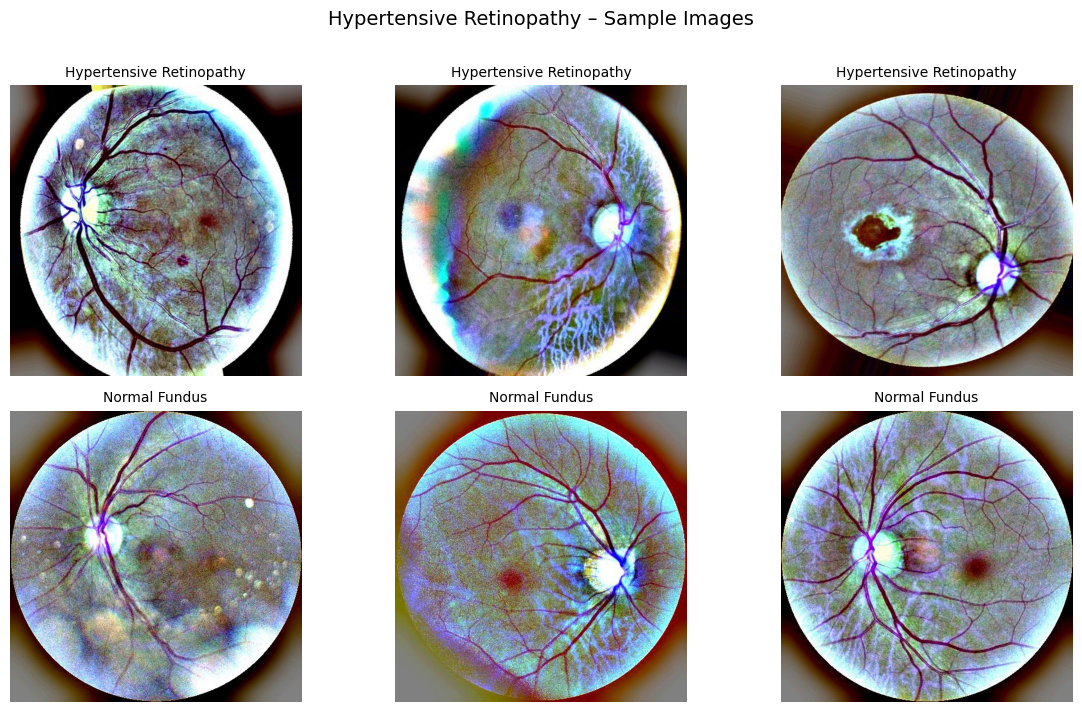


----- IMAGE STATISTICAL ANALYSIS -----
Total Images Analyzed               : 273
Unique Resolutions                  : 1
Width  – min / mean / max           : 512 / 512 / 512
Height – min / mean / max           : 512 / 512 / 512
File Size (MB) – min / mean / max   : 0.035 / 0.056 / 0.095
Channels (most common)              : 3




In [4]:
# Analysis
analyze_dataset(
    dataset_name = "Hypertensive Retinopathy",
    root_path    = "/kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset/Eye Disease dataset",
    class_folders = ["Normal Fundus", "Hypertensive Retinopathy"]
)

In [5]:
import json
import pandas as pd
from pathlib import Path
from datetime import datetime
from IPython.display import display

# ============================================================
# 1. PATHS DATABASE
# ============================================================
paths_db = {
    "group": "special-hr-etc",
    "created": datetime.now().isoformat(),
    "datasets": {
        "Hypertensive Retinopathy": {
            "kaggle_slug": "zoya77/hypertensive-retinopathy-fundus-image-dataset",
            "root": "/kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset/Eye Disease dataset",
            "images_folder": "/kaggle/input/datasets/zoya77/hypertensive-retinopathy-fundus-image-dataset/Eye Disease dataset",
            "type": "folder_based",
            "classes": ["Normal Fundus", "Hypertensive Retinopathy"],
            "notes": "Small specialized HR dataset"
        }
    }
}

# ============================================================
# 2. SUMMARY LOGS DB
# ============================================================
summary_db = {
    "group": "special-hr-etc",
    "created": datetime.now().isoformat(),
    "results": {
        # Fill after analysis
        # "Hypertensive Retinopathy": {
        #     "total_images": 273,
        #     "classes": {"Normal Fundus": 179, "Hypertensive Retinopathy": 94},
        #     "resolution": "...",
        #     "avg_size_mb": 0.05
        # }
    }
}

# ============================================================
# 3. MASTER TABLE + SIZE + TOTALS
# ============================================================
def get_folder_size_mb(folder_path: str) -> float:
    total = 0
    path = Path(folder_path)
    if not path.exists():
        return 0.0
    for f in path.rglob("*"):
        if f.is_file():
            total += f.stat().st_size
    return total / (1024 * 1024)

master_rows = []

for name, info in paths_db["datasets"].items():
    images_folder = info.get("images_folder") or info.get("root")
    size_mb = get_folder_size_mb(images_folder)
    result = summary_db["results"].get(name, {})
    
    master_rows.append({
        "Dataset": name,
        "Kaggle_Slug": info["kaggle_slug"],
        "Type": info["type"],
        "Num_Classes": len(info["classes"]),
        "Total_Images": result.get("total_images", 0),
        "Resolution": result.get("resolution", ""),
        "Avg_Size_MB": result.get("avg_size_mb", 0),
        "Total_Size_MB": round(size_mb, 1),
        "Total_Size_GB": round(size_mb / 1024, 2),
        "Classes": " | ".join(info["classes"]),
        "Per_Class_Counts": " | ".join(
            f"{cls}:{cnt}" for cls, cnt in result.get("classes", {}).items()
        ),
        "Root_Path": info["root"],
        "Images_Folder": images_folder,
        "Notes": info.get("notes", "")
    })

df_master = pd.DataFrame(master_rows)

total_images = df_master["Total_Images"].sum()
total_size_mb = df_master["Total_Size_MB"].sum()
total_size_gb = total_size_mb / 1024

print("=" * 80)
print("MASTER SUMMARY TABLE – special-hr-etc")
print("=" * 80)
display(df_master)

print("\n" + "=" * 80)
print("GRAND TOTALS")
print("=" * 80)
print(f"Total Datasets     : {len(df_master)}")
print(f"Total Images       : {total_images:,}")
print(f"Total Size         : {total_size_mb:,.1f} MB  ({total_size_gb:.2f} GB)")
print("=" * 80)

# Save
df_master.to_csv("/kaggle/working/special-hr-etc_master_table.csv", index=False)

with open("/kaggle/working/special-hr-etc_paths_db.json", "w") as f:
    json.dump(paths_db, f, indent=2)

with open("/kaggle/working/special-hr-etc_summary_db.json", "w") as f:
    json.dump(summary_db, f, indent=2)

print("\n✅ Files saved:")
print(" - special-hr-etc_paths_db.json")
print(" - special-hr-etc_summary_db.json")
print(" - special-hr-etc_master_table.csv")

MASTER SUMMARY TABLE – special-hr-etc


,Dataset,Kaggle_Slug,Type,Num_Classes,Total_Images,Resolution,Avg_Size_MB,Total_Size_MB,Total_Size_GB,Classes,Per_Class_Counts,Root_Path,Images_Folder,Notes
0,Hypertensive Retinopathy,zoya77/hypertensive-retinopathy-fundus-image-d...,folder_based,2,0,,0,15.2,0.01,Normal Fundus | Hypertensive Retinopathy,,/kaggle/input/datasets/zoya77/hypertensive-ret...,/kaggle/input/datasets/zoya77/hypertensive-ret...,Small specialized HR dataset



GRAND TOTALS
Total Datasets     : 1
Total Images       : 0
Total Size         : 15.2 MB  (0.01 GB)

✅ Files saved:
 - special-hr-etc_paths_db.json
 - special-hr-etc_summary_db.json
 - special-hr-etc_master_table.csv
